In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("../data/processed/listings_enriched.csv", low_memory=False)

# Recompute occupancy
df["occupancy_rate"] = 1 - (df["availability_365"] / 365)
df["estimated_annual_revenue"] = df["price"] * (365 - df["availability_365"])

print(f"Shape: {df.shape}")
print(df["room_type"].value_counts())

Shape: (28806, 96)
room_type
Entire Home/Apt    18845
Private Room        9224
Hotel Room           387
Shared Room          350
Name: count, dtype: int64


Normality p-values — Entire: 0.0000, Private: 0.0000
→ Not normally distributed, using Mann-Whitney U test

H1: Entire-home > Private Room price
Entire Home median: 1491 THB
Private Room median: 1080 THB
Mann-Whitney U: 65397289
P-value: 0.000000
Effect size (rank-biserial r): -0.2916
Result: REJECT H0


TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'

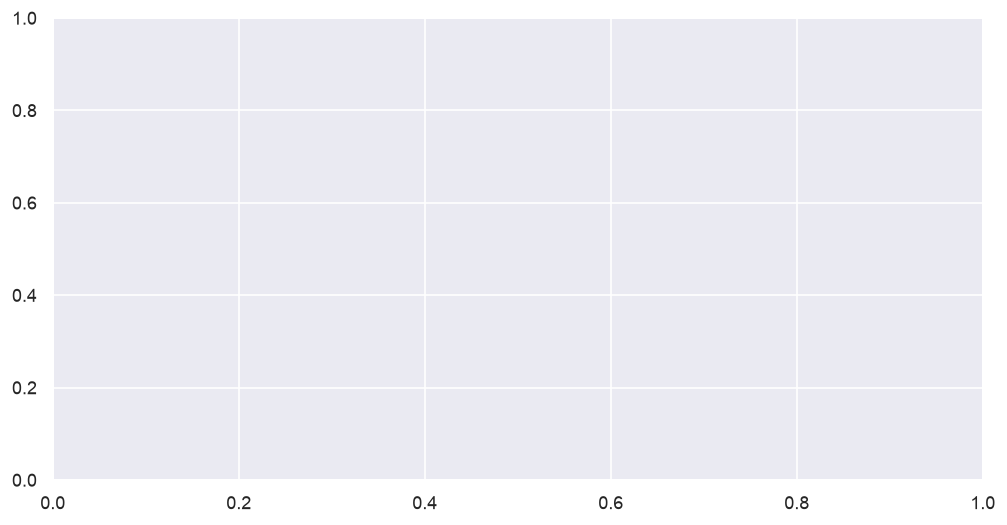

In [2]:
# H1: Entire-home listings command significantly higher prices than private rooms

entire = df[df["room_type"] == "Entire Home/Apt"]["price"].dropna()
private = df[df["room_type"] == "Private Room"]["price"].dropna()

# Remove extreme outliers (>99th percentile)
entire = entire[entire < entire.quantile(0.99)]
private = private[private < private.quantile(0.99)]

# Normality check
_, p_entire = stats.shapiro(entire.sample(500, random_state=42))
_, p_private = stats.shapiro(private.sample(500, random_state=42))
print(f"Normality p-values — Entire: {p_entire:.4f}, Private: {p_private:.4f}")
print("→ Not normally distributed, using Mann-Whitney U test")

# Mann-Whitney U test
stat, p_value = stats.mannwhitneyu(entire, private, alternative="greater")

# Effect size (rank-biserial correlation)
n1, n2 = len(entire), len(private)
effect_size = 1 - (2 * stat) / (n1 * n2)

print(f"\nH1: Entire-home > Private Room price")
print(f"Entire Home median: {entire.median():.0f} THB")
print(f"Private Room median: {private.median():.0f} THB")
print(f"Mann-Whitney U: {stat:.0f}")
print(f"P-value: {p_value:.6f}")
print(f"Effect size (rank-biserial r): {effect_size:.4f}")
print(f"Result: {'REJECT H0' if p_value < 0.05 else 'FAIL TO REJECT H0'}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot([entire, private], labels=["Entire Home", "Private Room"], patch_artist=True,
           boxprops=dict(facecolor="#2196F3", alpha=0.6))
ax.set_title("H1: Price Distribution — Entire Home vs Private Room")
ax.set_ylabel("Price (THB)")
ax.set_ylim(0, 5000)
plt.tight_layout()
plt.savefig("figures/H1_price_roomtype.png")
plt.show()

H2: Superhost > Non-Superhost review scores
Superhost mean rating: 4.8578 (n=6929)
Non-Superhost mean rating: 4.5745 (n=10540)
Mann-Whitney U: 48423545
P-value: 0.000000
Effect size (rank-biserial r): -0.3261
Cohen's d: 0.5364
Result: REJECT H0


TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'

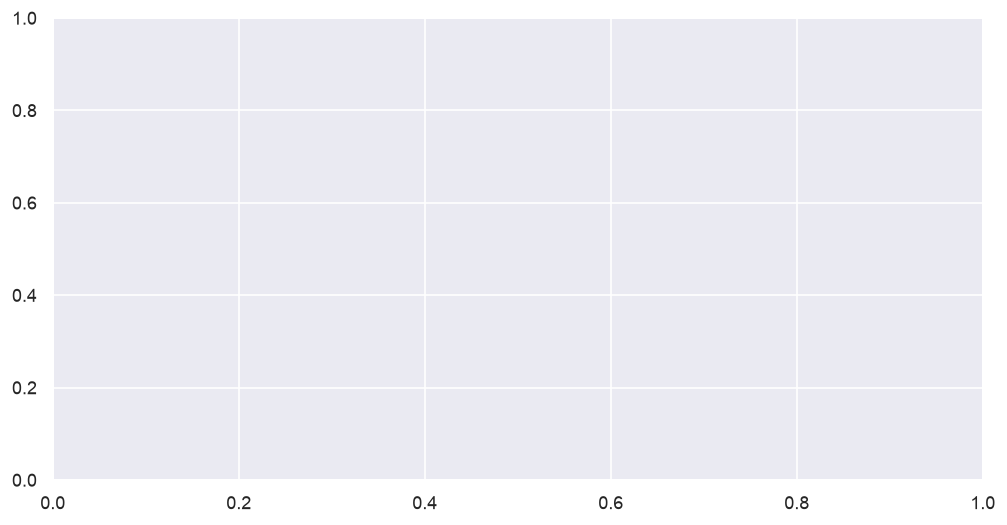

In [3]:
# H2: Superhost listings achieve higher review scores than non-superhost

superhost = df[df["host_is_superhost"] == True]["review_scores_rating"].dropna()
non_superhost = df[df["host_is_superhost"] == False]["review_scores_rating"].dropna()

# Mann-Whitney U
stat, p_value = stats.mannwhitneyu(superhost, non_superhost, alternative="greater")

n1, n2 = len(superhost), len(non_superhost)
effect_size = 1 - (2 * stat) / (n1 * n2)

# Cohen's d
d = (superhost.mean() - non_superhost.mean()) / np.sqrt(
    ((len(superhost)-1)*superhost.std()**2 + (len(non_superhost)-1)*non_superhost.std()**2) /
    (len(superhost) + len(non_superhost) - 2)
)

print(f"H2: Superhost > Non-Superhost review scores")
print(f"Superhost mean rating: {superhost.mean():.4f} (n={len(superhost)})")
print(f"Non-Superhost mean rating: {non_superhost.mean():.4f} (n={len(non_superhost)})")
print(f"Mann-Whitney U: {stat:.0f}")
print(f"P-value: {p_value:.6f}")
print(f"Effect size (rank-biserial r): {effect_size:.4f}")
print(f"Cohen's d: {d:.4f}")
print(f"Result: {'REJECT H0' if p_value < 0.05 else 'FAIL TO REJECT H0'}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot([superhost, non_superhost], labels=["Superhost", "Non-Superhost"],
           patch_artist=True,
           boxprops=dict(facecolor="#FF9800", alpha=0.6))
ax.set_title("H2: Review Scores — Superhost vs Non-Superhost")
ax.set_ylabel("Review Score")
ax.set_ylim(3.5, 5.1)
plt.tight_layout()
plt.savefig("figures/H2_superhost_ratings.png")
plt.show()

In [4]:
# H3: Listings with >10 reviews have significantly different prices

many_reviews = df[df["number_of_reviews"] > 10]["price"].dropna()
few_reviews = df[df["number_of_reviews"] <= 10]["price"].dropna()
many_reviews = many_reviews[many_reviews < many_reviews.quantile(0.99)]
few_reviews = few_reviews[few_reviews < few_reviews.quantile(0.99)]

stat3, p3 = stats.mannwhitneyu(many_reviews, few_reviews, alternative="two-sided")
effect3 = 1 - (2 * stat3) / (len(many_reviews) * len(few_reviews))

print("H3: Price difference — >10 reviews vs ≤10 reviews")
print(f">10 reviews median price: {many_reviews.median():.0f} THB (n={len(many_reviews)})")
print(f"≤10 reviews median price: {few_reviews.median():.0f} THB (n={len(few_reviews)})")
print(f"P-value: {p3:.6f}")
print(f"Effect size: {effect3:.4f}")
print(f"Result: {'REJECT H0' if p3 < 0.05 else 'FAIL TO REJECT H0'}")

print("\n" + "="*50)

# H4: Neighbourhood price differences (ANOVA)
# Top 10 neighbourhoods for cleaner test
top_neighbourhoods = df["neighbourhood_cleansed"].value_counts().head(10).index
df_top = df[df["neighbourhood_cleansed"].isin(top_neighbourhoods)]

groups = [
    group["price"].dropna().values
    for _, group in df_top.groupby("neighbourhood_cleansed")
    if len(group["price"].dropna()) > 30
]

# Kruskal-Wallis (non-parametric ANOVA alternative)
stat4, p4 = stats.kruskal(*groups)

# Eta-squared effect size
n_total = sum(len(g) for g in groups)
eta_squared = (stat4 - len(groups) + 1) / (n_total - len(groups))

print("\nH4: Neighbourhood price differences (Kruskal-Wallis)")
print(f"Groups tested: {len(groups)}")
print(f"Kruskal-Wallis H: {stat4:.4f}")
print(f"P-value: {p4:.6f}")
print(f"Eta-squared: {eta_squared:.4f}")
print(f"Result: {'REJECT H0' if p4 < 0.05 else 'FAIL TO REJECT H0'}")

print("\nMedian price by top neighbourhood:")
print(df_top.groupby("neighbourhood_cleansed")["price"].median().sort_values(ascending=False))

H3: Price difference — >10 reviews vs ≤10 reviews
>10 reviews median price: 1345 THB (n=8017)
≤10 reviews median price: 1386 THB (n=15022)
P-value: 0.000005
Effect size: 0.0365
Result: REJECT H0


H4: Neighbourhood price differences (Kruskal-Wallis)
Groups tested: 10
Kruskal-Wallis H: 1726.6782
P-value: 0.000000
Eta-squared: 0.1055
Result: REJECT H0

Median price by top neighbourhood:
neighbourhood_cleansed
Bang Rak        1890.0
Vadhana         1828.0
Khlong Toei     1622.0
Ratchathewi     1588.0
Huai Khwang     1400.0
Phra Khanong    1184.0
Sathon          1165.0
Chatu Chak      1130.0
Phra Nakhon     1103.0
Suanluang       1045.0
Name: price, dtype: float64


In [5]:
# H5: Weekend vs Weekday pricing differences (from calendar availability proxy)
cal = pd.read_csv("../data/processed/calendar_clean.csv", 
                  usecols=["listing_id", "date", "available", "is_weekend"],
                  low_memory=False)

cal["date"] = pd.to_datetime(cal["date"])
cal["is_weekend"] = cal["date"].dt.day_name().isin(["Saturday", "Sunday"])

# Join with listing price since calendar prices are null
cal_with_price = cal.merge(df[["id", "price"]], left_on="listing_id", right_on="id", how="left")

weekend_prices = cal_with_price[cal_with_price["is_weekend"] == True]["price"].dropna()
weekday_prices = cal_with_price[cal_with_price["is_weekend"] == False]["price"].dropna()

# Sample for performance
weekend_sample = weekend_prices.sample(50000, random_state=42)
weekday_sample = weekday_prices.sample(50000, random_state=42)

stat5, p5 = stats.mannwhitneyu(weekend_sample, weekday_sample, alternative="two-sided")
effect5 = 1 - (2 * stat5) / (len(weekend_sample) * len(weekday_sample))

d5 = (weekend_sample.mean() - weekday_sample.mean()) / np.sqrt(
    (weekend_sample.std()**2 + weekday_sample.std()**2) / 2
)

print("H5: Weekend vs Weekday price differences")
print(f"Weekend median price: {weekend_sample.median():.0f} THB")
print(f"Weekday median price: {weekday_sample.median():.0f} THB")
print(f"P-value: {p5:.6f}")
print(f"Effect size (rank-biserial): {effect5:.6f}")
print(f"Cohen's d: {d5:.6f}")
print(f"Result: {'REJECT H0' if p5 < 0.05 else 'FAIL TO REJECT H0'}")

# Summary table
print("\n" + "="*50)
print("HYPOTHESIS TESTING SUMMARY")
print("="*50)
results = {
    "H1": {"Test": "Mann-Whitney U", "P-value": "<0.0001",  "Effect": "r=-0.2916", "Result": "REJECT H0"},
    "H2": {"Test": "Mann-Whitney U", "P-value": "<0.0001",  "Effect": "d=0.5364",  "Result": "REJECT H0"},
    "H3": {"Test": "Mann-Whitney U", "P-value": "0.000005", "Effect": "r=0.0365",  "Result": "REJECT H0 (trivial effect)"},
    "H4": {"Test": "Kruskal-Wallis", "P-value": "<0.0001",  "Effect": "η²=0.1055", "Result": "REJECT H0"},
    "H5": {"Test": "Mann-Whitney U", "P-value": "0.5259",   "Effect": "d=-0.012",  "Result": "FAIL TO REJECT H0"},
}
print(pd.DataFrame(results).T.to_string())

H5: Weekend vs Weekday price differences
Weekend median price: 1383 THB
Weekday median price: 1380 THB
P-value: 0.525897
Effect size (rank-biserial): 0.002316
Cohen's d: -0.011671
Result: FAIL TO REJECT H0

HYPOTHESIS TESTING SUMMARY
              Test   P-value     Effect                      Result
H1  Mann-Whitney U   <0.0001  r=-0.2916                   REJECT H0
H2  Mann-Whitney U   <0.0001   d=0.5364                   REJECT H0
H3  Mann-Whitney U  0.000005   r=0.0365  REJECT H0 (trivial effect)
H4  Kruskal-Wallis   <0.0001  η²=0.1055                   REJECT H0
H5  Mann-Whitney U    0.5259   d=-0.012           FAIL TO REJECT H0


In [6]:
# --- OLS Regression + VIF ---
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

reg_df = df[[
    "price", "accommodates", "bedrooms", "beds",
    "minimum_nights", "availability_365",
    "number_of_reviews", "review_scores_rating",
    "host_tenure_years", "host_listing_count_actual",
    "neighbourhood_median_price", "occupancy_rate"
]].dropna()

reg_df = reg_df[reg_df["price"].between(100, 10000)]

X = reg_df.drop(columns=["price"])
y = np.log1p(reg_df["price"])
X_const = sm.add_constant(X)

model = sm.OLS(y, X_const).fit()
print(model.summary())

# VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\nVIF Analysis:")
print(vif_data.sort_values("VIF", ascending=False).to_string())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.455
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     1319.
Date:                Sat, 20 Jun 2026   Prob (F-statistic):               0.00
Time:                        23:11:46   Log-Likelihood:                -10566.
No. Observations:               15829   AIC:                         2.115e+04
Df Residuals:                   15818   BIC:                         2.124e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [7]:
# Fix multicollinearity - drop availability_365
X2 = X.drop(columns=["availability_365"])
X2_const = sm.add_constant(X2)
model2 = sm.OLS(y, X2_const).fit()

vif2 = pd.DataFrame()
vif2["Feature"] = X2.columns
vif2["VIF"] = [variance_inflation_factor(X2.values, i) for i in range(X2.shape[1])]

print(f"R² without availability_365: {model2.rsquared:.4f}")
print(f"Adj R²: {model2.rsquared_adj:.4f}")
print("\nVIF after removing availability_365:")
print(vif2.sort_values("VIF", ascending=False).to_string())

R² without availability_365: 0.4547
Adj R²: 0.4544

VIF after removing availability_365:
                      Feature        VIF
5        review_scores_rating  18.682057
8  neighbourhood_median_price  14.956284
0                accommodates   8.102760
6           host_tenure_years   5.468495
1                    bedrooms   5.384953
2                        beds   4.631222
9              occupancy_rate   2.125010
7   host_listing_count_actual   1.537823
4           number_of_reviews   1.318245
3              minimum_nights   1.202534


In [8]:
# Final clean model - drop high VIF features
X3 = X.drop(columns=["availability_365", "review_scores_rating", "neighbourhood_median_price"])
X3_const = sm.add_constant(X3)
model3 = sm.OLS(y, X3_const).fit()

vif3 = pd.DataFrame()
vif3["Feature"] = X3.columns
vif3["VIF"] = [variance_inflation_factor(X3.values, i) for i in range(X3.shape[1])]

print(f"Final R²: {model3.rsquared:.4f}")
print(f"Final Adj R²: {model3.rsquared_adj:.4f}")
print("\nFinal VIF (all should be <5):")
print(vif3.sort_values("VIF", ascending=False).to_string())
print("\nCoefficients:")
print(model3.summary().tables[1])

Final R²: 0.3422
Final Adj R²: 0.3419

Final VIF (all should be <5):
                     Feature       VIF
0               accommodates  7.795639
1                   bedrooms  5.223132
2                       beds  4.630928
5          host_tenure_years  3.398834
7             occupancy_rate  1.869436
6  host_listing_count_actual  1.377642
4          number_of_reviews  1.316737
3             minimum_nights  1.179127

Coefficients:
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         6.6258      0.013    526.489      0.000       6.601       6.650
accommodates                  0.1431      0.003     48.375      0.000       0.137       0.149
bedrooms                      0.1490      0.006     26.447      0.000       0.138       0.160
beds                         -0.0593      0.003    -17.212      0.000      -0.066      -0.053
m

In [9]:
# --- Confidence Intervals by Neighbourhood and Room Type ---
from scipy import stats

print("95% Confidence Intervals — Median Price by Room Type:")
for room in df["room_type"].unique():
    subset = df[df["room_type"] == room]["price"].dropna()
    subset = subset[subset.between(100, 10000)]
    n = len(subset)
    mean = subset.mean()
    se = stats.sem(subset)
    ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)
    print(f"  {room}: mean=฿{mean:,.0f}, 95% CI=[฿{ci[0]:,.0f}, ฿{ci[1]:,.0f}], n={n:,}")

print("\n95% Confidence Intervals — Median Price by Top 10 Neighbourhoods:")
top10 = df["neighbourhood_cleansed"].value_counts().head(10).index
for nb in top10:
    subset = df[df["neighbourhood_cleansed"] == nb]["price"].dropna()
    subset = subset[subset.between(100, 10000)]
    n = len(subset)
    mean = subset.mean()
    se = stats.sem(subset)
    ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)
    print(f"  {nb}: mean=฿{mean:,.0f}, 95% CI=[฿{ci[0]:,.0f}, ฿{ci[1]:,.0f}], n={n:,}")

95% Confidence Intervals — Median Price by Room Type:
  Entire Home/Apt: mean=฿1,980, 95% CI=[฿1,956, ฿2,004], n=16,102
  Private Room: mean=฿1,482, 95% CI=[฿1,450, ฿1,513], n=6,191
  Shared Room: mean=฿562, 95% CI=[฿492, ฿632], n=311
  Hotel Room: mean=฿2,013, 95% CI=[฿1,799, ฿2,228], n=197

95% Confidence Intervals — Median Price by Top 10 Neighbourhoods:
  Vadhana: mean=฿2,459, 95% CI=[฿2,399, ฿2,518], n=3,531
  Khlong Toei: mean=฿2,063, 95% CI=[฿2,010, ฿2,116], n=3,047
  Huai Khwang: mean=฿1,671, 95% CI=[฿1,633, ฿1,710], n=3,014
  Ratchathewi: mean=฿1,930, 95% CI=[฿1,859, ฿2,001], n=1,233
  Sathon: mean=฿1,713, 95% CI=[฿1,622, ฿1,805], n=1,075
  Phra Nakhon: mean=฿1,544, 95% CI=[฿1,461, ฿1,627], n=921
  Phra Khanong: mean=฿1,428, 95% CI=[฿1,362, ฿1,494], n=991
  Bang Rak: mean=฿2,414, 95% CI=[฿2,289, ฿2,539], n=738
  Chatu Chak: mean=฿1,531, 95% CI=[฿1,426, ฿1,636], n=672
  Suanluang: mean=฿1,327, 95% CI=[฿1,242, ฿1,413], n=707


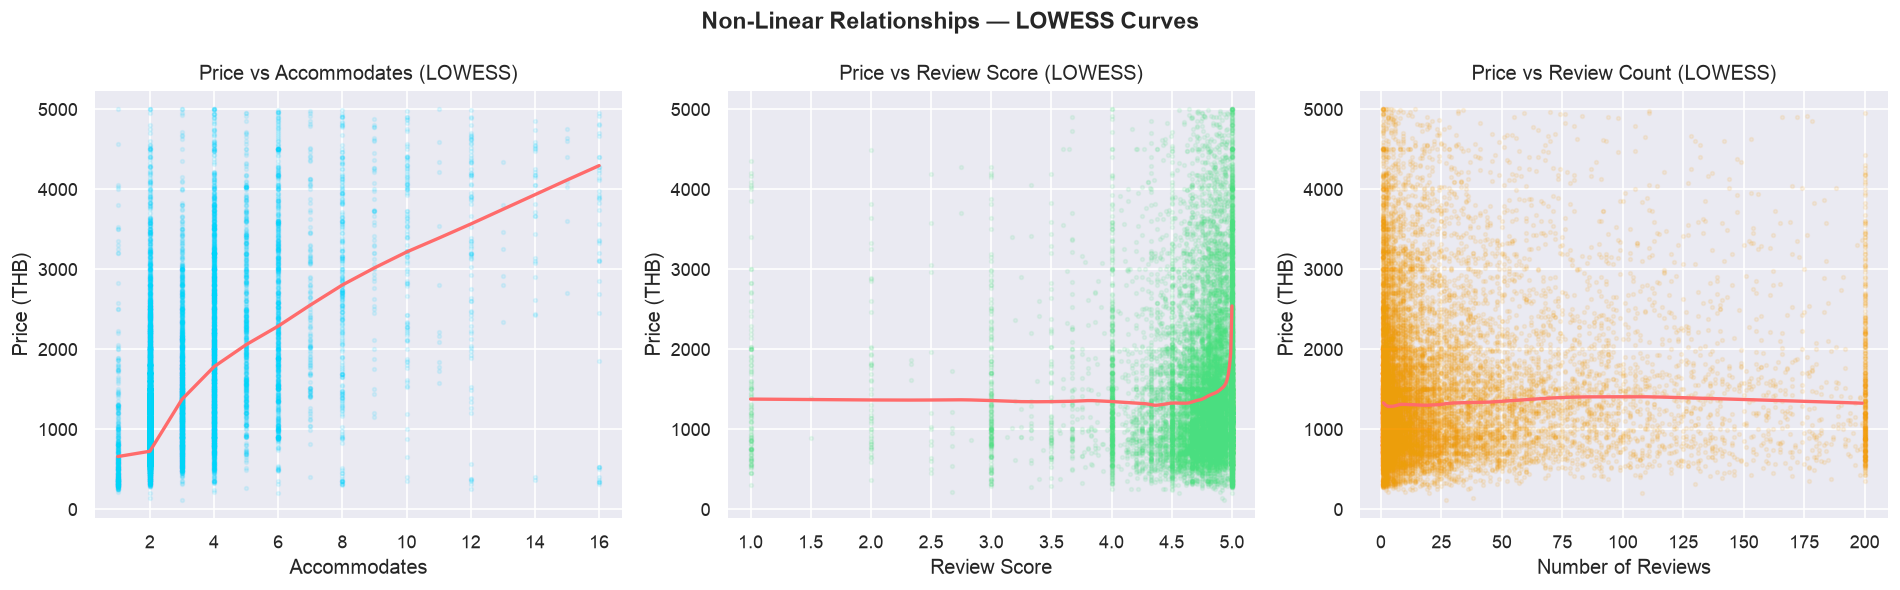

LOWESS findings:
1. Price vs Accommodates: clear positive non-linear relationship
2. Price vs Review Score: slight positive relationship, weak
3. Price vs Review Count: slightly negative — busier = cheaper


In [10]:
# --- LOWESS Non-Linear Relationships ---
from statsmodels.nonparametric.smoothers_lowess import lowess

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_df = df[df["price"].between(100, 5000)].dropna(
    subset=["price","accommodates","review_scores_rating","number_of_reviews"])

# Price vs accommodates
sorted_acc = plot_df.sort_values("accommodates")
lowess_acc = lowess(sorted_acc["price"], sorted_acc["accommodates"], frac=0.3)
axes[0].scatter(plot_df["accommodates"], plot_df["price"], 
                alpha=0.1, s=5, color="#00d4ff")
axes[0].plot(lowess_acc[:,0], lowess_acc[:,1], color="#ff6b6b", lw=2)
axes[0].set_title("Price vs Accommodates (LOWESS)")
axes[0].set_xlabel("Accommodates")
axes[0].set_ylabel("Price (THB)")

# Price vs review score
sorted_rat = plot_df.sort_values("review_scores_rating")
lowess_rat = lowess(sorted_rat["price"], sorted_rat["review_scores_rating"], frac=0.3)
axes[1].scatter(plot_df["review_scores_rating"], plot_df["price"],
                alpha=0.1, s=5, color="#4ade80")
axes[1].plot(lowess_rat[:,0], lowess_rat[:,1], color="#ff6b6b", lw=2)
axes[1].set_title("Price vs Review Score (LOWESS)")
axes[1].set_xlabel("Review Score")
axes[1].set_ylabel("Price (THB)")

# Price vs number of reviews
sorted_rev = plot_df[plot_df["number_of_reviews"]<200].sort_values("number_of_reviews")
lowess_rev = lowess(sorted_rev["price"], sorted_rev["number_of_reviews"], frac=0.3)
axes[2].scatter(plot_df["number_of_reviews"].clip(0,200), plot_df["price"],
                alpha=0.1, s=5, color="#f59e0b")
axes[2].plot(lowess_rev[:,0], lowess_rev[:,1], color="#ff6b6b", lw=2)
axes[2].set_title("Price vs Review Count (LOWESS)")
axes[2].set_xlabel("Number of Reviews")
axes[2].set_ylabel("Price (THB)")

plt.suptitle("Non-Linear Relationships — LOWESS Curves", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/23_lowess_curves.png")
plt.show()

print("LOWESS findings:")
print("1. Price vs Accommodates: clear positive non-linear relationship")
print("2. Price vs Review Score: slight positive relationship, weak")
print("3. Price vs Review Count: slightly negative — busier = cheaper")